<a href="https://colab.research.google.com/github/Mayfm/wildlife-bacterial-dynamics/blob/main/Project_code_wildlife_and_bacterial_dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dinámica temporal de los aislamientos bacterianos asociados a animales silvestres

## Introducción

Los animales silvestres pueden albergar una gran diversidad de microorganismos asociados con diferentes tejidos, ambientes y condiciones ecológicas. Las bases de datos genómicas permiten reunir información de numerosos aislamientos bacterianos junto con datos sobre el hospedero, el lugar y el momento de aislamiento y características del genoma.

En este proyecto se analizarán registros de genomas bacterianos asociados a diferentes animales silvestres para explorar cómo se distribuyen los grupos bacterianos a través del tiempo y si esta distribución presenta diferencias geográficas.

## Pregunta de investigación

¿Cómo ha cambiado a través del tiempo la distribución de los grupos bacterianos asociados a animales silvestres?

##Objetivos

Analizar la distribución temporal de los grupos bacterianos asociados a animales silvestres y explorar su relación con el hospedero y la ubicación geográfica a partir de datos genómicos disponibles en BV-BRC.

###Objetivos específicos

* Caracterizar los registros de genomas bacterianos asociados a diferentes animales silvestres.
* Describir la distribución de los aislamientos bacterianos a través del tiempo.
* Comparar la composición taxonómica bacteriana entre diferentes grupos de hospederos.
* Explorar la distribución geográfica de los registros bacterianos.
* Analizar algunas características genómicas, como tamaño del genoma y contenido de GC.
* Identificar patrones temporales, biológicos y geográficos dentro del conjunto de datos.





## Fuente de datos

Los datos fueron obtenidos de BV-BRC (Bacterial and Viral Bioinformatics Resource Center), utilizando la sección Genomes y realizando búsquedas por hospedero (`Host Common Name`).

Se seleccionaron diferentes hospederos pertenecientes a fauna silvestre y sus registros genómicos fueron descargados individualmente en formato CSV. Posteriormente, los archivos fueron integrados en un único conjunto de datos.

### Carga de la base de datos

Los archivos CSV descargados de BV-BRC contenían información sobre los genomas bacterianos asociados a los diferentes hospederos seleccionados. Debido a que presentaban una estructura de columnas compatible, los archivos se integraron verticalmente mediante ` pandas.concat()`, conservando los registros de cada archivo.

In [3]:
import pandas as pd
import glob

# Buscar todos los archivos de BV-BRC
archivos = glob.glob("/content/BVBRC_genome_*.csv")

# Leer cada archivo
tablas = [pd.read_csv(archivo) for archivo in archivos]

# Unir todas las tablas
wildlife = pd.concat(tablas, ignore_index=True)

print("Filas:", wildlife.shape[0])
print("Columnas:", wildlife.shape[1])

Filas: 13794
Columnas: 90


La base de datos estuvo conformada por 13,794 registros y 90 variables.


## Exploración de los datos

Se mostraron los primeros registros del conjunto de datos para verificar que la información se hubiera cargado correctamente y observar su estructura general.

In [6]:
wildlife.head()

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Host Age,Host Health,Host Group,Lab Host,Passage,Other Clinical,Additional Metadata,Comments,Date Inserted,Date Modified
0,1017266.300,Lactococcus garvieae UNIUD074,NaN,1017266,131567;2;1783272;1239;91061;186826;1300;1357;1...,cellular organisms;Bacteria;Bacillati;Bacillot...,Bacteria,Bacillati,Bacillota,Bacilli,...,NaN,NaN,Fish,NaN,NaN,NaN,NaN,The strain Lactococcus garvieae UNIUD074 is be...,2014-12-08T22:11:55.166Z,2015-03-16T03:17:09.594Z
1,1037377.300,Chryseobacterium viscerum strain 687B-08,NaN,1037377,131567;2;3379134;1783270;68336;976;117743;2006...,cellular organisms;Bacteria;Pseudomonadati;FCB...,Bacteria,Pseudomonadati,Bacteroidota,Flavobacteriia,...,NaN,NaN,Fish,NaN,NaN,NaN,sample_type:cell culture,Chryseobacterium viscerum 687B-08 Genome seque...,2018-05-25T20:10:36.051Z,2018-05-25T20:10:36.051Z
2,105751.600,Aeromonas bestiarum strain GA97-22,NaN,105751,131567;2;3379134;1224;1236;135624;84642;642;10...,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,Fish,NaN,NaN,NaN,sample_type:whole organism,Aeromonas bestiarum belongs a group of mesophi...,2018-05-25T20:59:32.581Z,2018-05-25T20:59:32.581Z
3,107401.175,Tenacibaculum maritimum TCFB 0814,NaN,107401,131567;2;3379134;1783270;68336;976;117743;2006...,cellular organisms;Bacteria;Pseudomonadati;FCB...,Bacteria,Pseudomonadati,Bacteroidota,Flavobacteriia,...,NaN,NaN,Fish,NaN,NaN,NaN,sample_type:cell culture;biomaterial_provider:...,NaN,2025-01-31T03:50:21.277Z,2025-01-31T03:50:21.277Z
4,107401.177,Tenacibaculum maritimum TCFB 0856,NaN,107401,131567;2;3379134;1783270;68336;976;117743;2006...,cellular organisms;Bacteria;Pseudomonadati;FCB...,Bacteria,Pseudomonadati,Bacteroidota,Flavobacteriia,...,NaN,NaN,Fish,NaN,NaN,NaN,sample_type:cell culture;biomaterial_provider:...,NaN,2025-01-31T03:52:27.738Z,2025-01-31T03:52:27.738Z


### Información general de las variables

Se utilizó `info()` para conocer la estructura del conjunto de datos, sus tipos de datos y los valores no nulos, lo que permitió identificar datos faltantes y seleccionar las variables útiles para el análisis.

In [7]:
wildlife.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13794 entries, 0 to 13793
Data columns (total 90 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Genome ID             13794 non-null  float64
 1   Genome Name           13794 non-null  object 
 2   Other Names           0 non-null      float64
 3   NCBI Taxon ID         13794 non-null  int64  
 4   Taxon Lineage IDs     13794 non-null  object 
 5   Taxon Lineage Names   13794 non-null  object 
 6   Superkingdom          13794 non-null  object 
 7   Kingdom               13622 non-null  object 
 8   Phylum                13700 non-null  object 
 9   Class                 13374 non-null  object 
 10  Order                 12405 non-null  object 
 11  Family                11635 non-null  object 
 12  Genus                 9840 non-null   object 
 13  Species               13794 non-null  object 
 14  Genome Status         13781 non-null  object 
 15  Strain             

## Revisión de valores faltantes

Se identificaron las columnas que no contenían ningún valor en el conjunto de datos. Estas variables fueron consideradas para su exclusión, debido a que no aportaban información para los análisis posteriores.

In [16]:
# Identificar las columnas  vacías
columnas_vacias = wildlife.columns[wildlife.isna().all()]

print("Número de columnas vacías:", len(columnas_vacias))

Número de columnas vacías: 20


In [15]:
print("\nColumnas  vacías:")
columnas_vacias.tolist()


Columnas  vacías:


['Other Names',
 'Segment',
 'Subtype',
 'H_type',
 'N_type',
 'H1 Clade Global',
 'H1 Clade US',
 'H5 Clade',
 'pH1N1-like',
 'Lineage',
 'Clade',
 'Subclade',
 'Authors',
 'Chromosome',
 'Mat Peptide',
 'Season',
 'County',
 'City',
 'Lab Host',
 'Passage']

### Eliminación de las columnas vacías

Se identificaron 20 variables que no contenían ningún valor en los 13,794 registros. Debido a que estas variables no aportaban información para el análisis, fueron eliminadas del conjunto de datos.

In [19]:
# Eliminar las columnas que no contienen ningún valor
wildlife = wildlife.drop(columns=columnas_vacias)

# Comprobar las nuevas dimensiones de la base
print("Filas:", wildlife.shape[0])
print("Columnas:", wildlife.shape[1])

Filas: 13794
Columnas: 70


In [32]:
# Verificar que ya no existan columnas completamente vacías
columnas_vacias = wildlife.columns[wildlife.isna().all()]

print("Columnas vacías restantes:", len(columnas_vacias))

Columnas vacías restantes: 0


## Selección de variables de interés

Después de eliminar las variables completamente vacías, se seleccionaron las variables relacionadas con las dimensiones principales del proyecto: tiempo, taxonomía bacteriana, hospedero, ubicación geográfica y características genómicas.

In [33]:
variables_interes = [
    "Genome ID",
    "Phylum",
    "Class",
    "Order",
    "Family",
    "Genus",
    "Species",
    "Collection Year",
    "Collection Date",
    "Host Common Name",
    "Host Group",
    "Host Health",
    "Isolation Country",
    "State/Province",
    "Geographic Group",
    "Size",
    "GC Content",
    "CDS",
    "Contigs",
    "CheckM Completeness"
]

wildlife[variables_interes].head()

,Genome ID,Phylum,Class,Order,Family,Genus,Species,Collection Year,Collection Date,Host Common Name,Host Group,Host Health,Isolation Country,State/Province,Geographic Group,Size,GC Content,CDS,Contigs,CheckM Completeness
0,1017266.3,Bacillota,Bacilli,Lactobacillales,Streptococcaceae,Lactococcus,Lactococcus garvieae,NaN,NaN,Rainbow Trout,Fish,NaN,Italy,NaN,Europe,2171472,38.680000,2120,25,100.0
1,1037377.3,Bacteroidota,Flavobacteriia,Flavobacteriales,Weeksellaceae,Chryseobacterium,Chryseobacterium viscerum,2017.0,2017-06,Trout,Fish,NaN,Spain,NaN,Europe,5741890,35.872627,6009,703,100.0
2,105751.6,Pseudomonadota,Gammaproteobacteria,Aeromonadales,Aeromonadaceae,Aeromonas,Aeromonas bestiarum,1997.0,1997,Trout,Fish,NaN,USA,Georgia,North America,4714837,60.505210,4473,26,100.0
3,107401.175,Bacteroidota,Flavobacteriia,Flavobacteriales,Flavobacteriaceae,Tenacibaculum,Tenacibaculum maritimum,1999.0,1999,Rainbow Trout,Fish,NaN,Australia,NaN,Oceania,3405213,31.640928,3327,223,100.0
4,107401.177,Bacteroidota,Flavobacteriia,Flavobacteriales,Flavobacteriaceae,Tenacibaculum,Tenacibaculum maritimum,2000.0,2000,Rainbow Trout,Fish,NaN,Australia,NaN,Oceania,3187672,31.924960,3112,437,99.8


In [34]:
wildlife[variables_interes].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13794 entries, 0 to 13793
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Genome ID            13794 non-null  string 
 1   Phylum               13700 non-null  object 
 2   Class                13374 non-null  object 
 3   Order                12405 non-null  object 
 4   Family               11635 non-null  object 
 5   Genus                9840 non-null   object 
 6   Species              13794 non-null  object 
 7   Collection Year      12456 non-null  float64
 8   Collection Date      12871 non-null  object 
 9   Host Common Name     12716 non-null  object 
 10  Host Group           12716 non-null  object 
 11  Host Health          1221 non-null   object 
 12  Isolation Country    10259 non-null  object 
 13  State/Province       1277 non-null   object 
 14  Geographic Group     8488 non-null   object 
 15  Size                 13794 non-null 

Se revisó la cantidad de valores faltantes en las variables seleccionadas para el análisis. Esta evaluación permitió identificar qué variables presentaban información incompleta y determinar posteriormente el tratamiento más adecuado para cada una.

In [35]:
# Calcular valores faltantes en las variables de interés
faltantes_interes = pd.DataFrame({
    "Valores faltantes": wildlife[variables_interes].isna().sum(),
    "Porcentaje": (
        wildlife[variables_interes].isna().sum() / len(wildlife) * 100
    ).round(2)
})

# Mostrar las variables con valores faltantes
faltantes_interes[faltantes_interes["Valores faltantes"] > 0] \
    .sort_values("Porcentaje", ascending=False)

,Valores faltantes,Porcentaje
Host Health,12573,91.15
State/Province,12517,90.74
Geographic Group,5306,38.47
Genus,3954,28.66
Isolation Country,3535,25.63
Family,2159,15.65
Order,1389,10.07
Collection Year,1338,9.70
Host Common Name,1078,7.81
Host Group,1078,7.81


Se observó que la cantidad de valores faltantes varió considerablemente entre las variables seleccionadas. Las variables `Host Health` y `State/Province` presentaron más del 90 % de valores faltantes, por lo que no fueron consideradas variables principales para el análisis. En contraste, variables como `Phylum, GC Content, Class y CheckM Completeness `presentaron una proporción baja de valores faltantes.

## Transformación de tipos de datos

Después de revisar las variables de interés, se realizaron algunas conversiones de tipo de dato para facilitar su análisis. Los identificadores se trataron como variables de texto, mientras que las variables temporales se transformaron a formatos adecuados para su procesamiento.

In [36]:
# Convertir Genome ID a texto, ya que corresponde a un identificador
# y no a una variable numérica
wildlife["Genome ID"] = wildlife["Genome ID"].astype("string")

# Convertir Collection Date a formato de fecha
wildlife["Collection Date"] = pd.to_datetime(
    wildlife["Collection Date"],
    errors="coerce"
)

# Convertir Collection Year a entero conservando los valores faltantes
wildlife["Collection Year"] = wildlife["Collection Year"].astype("Int64")

# Comprobar el cambio en los tipos de datos
print(wildlife[
    ["Genome ID", "Collection Date", "Collection Year"]
].dtypes)

Genome ID          string[python]
Collection Date    datetime64[ns]
Collection Year             Int64
dtype: object


Se verificaron los tipos de datos de las variables transformadas para confirmar que cada una se encontrara en un formato adecuado para su análisis.

In [37]:
wildlife[[
    "Genome ID",
    "Collection Date",
    "Collection Year"
]].head()

,Genome ID,Collection Date,Collection Year
0,1017266.3,NaT,<NA>
1,1037377.3,2017-06-01,2017
2,105751.6,NaT,1997
3,107401.175,NaT,1999
4,107401.177,NaT,2000


In [38]:
print("Año mínimo:", wildlife["Collection Year"].min())
print("Año máximo:", wildlife["Collection Year"].max())
print("Valores faltantes:", wildlife["Collection Year"].isna().sum())

Año mínimo: 1900
Año máximo: 2025
Valores faltantes: 1338


In [39]:
wildlife["Collection Year"].describe()

,Collection Year
count,12456.0
mean,2015.302906
std,7.035405
min,1900.0
25%,2014.0
50%,2018.0
75%,2018.0
max,2025.0


### Exportación de la base procesada

Una vez finalizada la etapa de limpieza y preparación, se exportó el conjunto de datos procesado en formato CSV para conservar una copia de trabajo y facilitar su reutilización en las etapas posteriores del análisis.

In [40]:
# Guardar la base procesada
ruta_salida = "/content/BVBRC_wildlife_procesada.csv"

wildlife.to_csv(ruta_salida, index=False)

print("Base procesada guardada en:", ruta_salida)

Base procesada guardada en: /content/BVBRC_wildlife_procesada.csv


In [41]:
import os

print("Archivo creado:", os.path.exists(ruta_salida))

Archivo creado: True


## Análisis exploratorio de los datos

### Distribución de los registros según el hospedero

Se revisó la distribución de los datos según el hospederos para identificar cuáles tienen mayor representación en la base de datos. Esta variable permitió identificar los hospederos más representados y observar diferencias en el nivel de detalle de las denominaciones utilizadas en BV-BRC.

In [52]:
# Frecuencia  por hospederos
frecuencia_hospederos = (
    wildlife["Host Common Name"]
    .value_counts()
)
frecuencia_hospederos.head(15)

,count
Host Common Name,
Deer,2334
Rainbow Trout,1158
Koala,877
Honeybee,737
Vole,717
Honey Bee,715
Rhesus macaque,572
Atlantic Salmon,570
Mallard,442


La distribución de los datos entre los hospederos fue heterogénea. Deer presentó la mayor cantidad de datos, con 2,334 (18.35 %), seguido de Rainbow Trout, con 1,158 (9.11 %). También se encontraron nombres diferentes que podrían corresponder a hospederos relacionados, como Honeybee y Honey Bee. Debido a que Host Common Name combina nombres generales y específicos, esta variable se conservará para describir los hospederos, pero no se utilizará como variable principal para realizar comparaciones entre grupos.

### Distribución por grupo de hospedero

Para facilitar la comparación entre los diferentes tipos de hospederos, se examinó la variable `Host Group`, que permitió agrupar los datos en categorías generales.

In [48]:
porcentaje_hospederos = (
    wildlife["Host Common Name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
porcentaje_hospederos.head(15)


,proportion
Host Common Name,
Deer,18.35
Rainbow Trout,9.11
Koala,6.90
Honeybee,5.80
Vole,5.64
Honey Bee,5.62
Rhesus macaque,4.50
Atlantic Salmon,4.48
Mallard,3.48


In [51]:
frecuencia_grupos = wildlife["Host Group"].value_counts()

frecuencia_grupos

,count
Host Group,
Nonhuman Mammal,7326
Fish,2169
Insect,1452
Avian,1200
Sea Mammal,390
Plant,114
Tick,38
Human,27


La distribución por grupos de hospederos mostró una mayor representación de mamíferos no humanos, con 7,326 datos, seguidos por peces (2,169), insectos (1,452) y aves (1,200). Los mamíferos no humanos representaron aproximadamente la mitad del conjunto de datos, lo que muestra una representación desigual entre los grupos de hospederos. También se identificaron registros clasificados como Plant y Human, que no corresponden a animales silvestres.

### Selección del conjunto de datos para el análisis

A partir de la clasificación de `Host Group`, se generó un conjunto de datos para los análisis posteriores, excluyendo los datos asociados con humanos y plantas. Debido a que el objetivo del proyecto se centró en aislamientos bacterianos asociados con animales silvestres.

In [53]:
wildlife_animales = wildlife[
    ~wildlife["Host Group"].isin(["Human", "Plant"])
].copy()

print("Registros antes:", len(wildlife))
print("Registros de animales:", len(wildlife_animales))

Registros antes: 13794
Registros de animales: 13653


### Distribución temporal

Se analizó la distribución de los datos según el año de colección (`Collection Year`) para conocer el periodo de tiempo representado en la base y observar cómo se distribuyeron los aislamientos bacterianos a través del tiempo.

In [54]:
print("Año mínimo:", wildlife_animales["Collection Year"].min())
print("Año máximo:", wildlife_animales["Collection Year"].max())
print("Datos sin año:", wildlife_animales["Collection Year"].isna().sum())

Año mínimo: 1900
Año máximo: 2025
Datos sin año: 1338


Los resultados mostraron una distribución temporal de 1900 a 2025. De los 13,653 datos asociados con hospederos animales, 1,338 no presentaron información sobre el año de colección.

#### Estadística descriptiva del año de colección

Se calcularon medidas descriptivas de `Collection Year` para conocer la distribución temporal de los datos disponibles.

In [55]:
wildlife_animales["Collection Year"].describe()

,Collection Year
count,12315.0
mean,2015.297523
std,7.026943
min,1900.0
25%,2014.0
50%,2018.0
75%,2018.0
max,2025.0


De los 13,653 datos asociados con hospederos animales, 12,315 contaron con información sobre el año de colección. La media fue de 2015.30 años y la desviación estándar de 7.03 años. El periodo comprendió de 1900 a 2025, mientras que la mediana fue de 2018. El 50 % central de los datos se encontró entre 2014 y 2018.

## Distribución de los aislamientos por año

Para visualizar la distribución temporal de los aislamientos bacterianos, se calculó la cantidad de datos disponibles para cada año de colección.

In [56]:
aislamientos_por_anio = (
    wildlife_animales["Collection Year"]
    .value_counts()
    .sort_index()
)

aislamientos_por_anio

,count
Collection Year,
1900,1
1930,2
1932,1
1938,1
1946,3
...,...
2021,353
2022,408
2023,129


Se encontraron datos para 71 años, desde 1900 hasta 2025. La cantidad de aislamientos fue considerablemente menor durante las primeras décadas y aumentó progresivamente hacia los años más recientes.

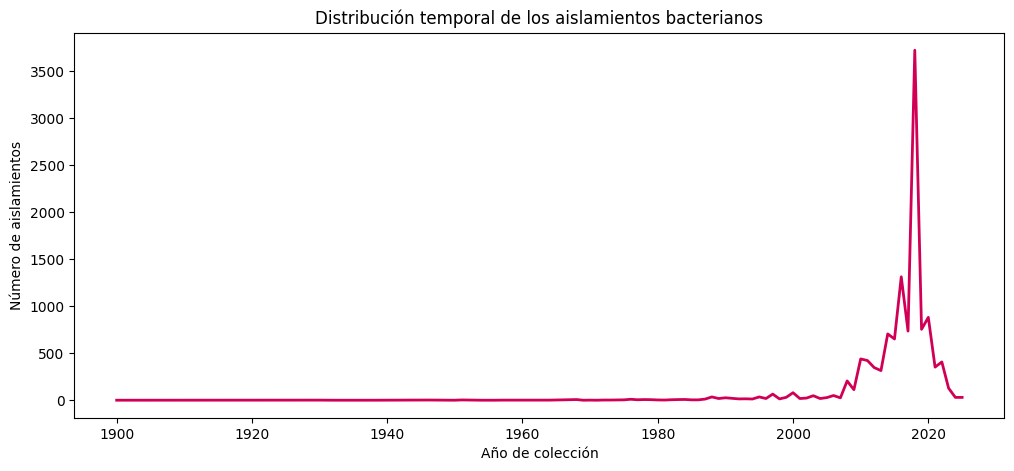

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    aislamientos_por_anio.index,
    aislamientos_por_anio.values,
    color="#D10056",
    linewidth=2
)

plt.xlabel("Año de colección")
plt.ylabel("Número de aislamientos")
plt.title("Distribución temporal de los aislamientos bacterianos")

plt.show()

La distribución temporal mostró una mayor concentración de los aislamientos en los años más recientes. Entre 1900 y aproximadamente la década de 1980, la cantidad de aislamientos fue baja. A partir de las décadas de 1990 y 2000 se observó un aumento progresivo, que fue más marcado durante la década de 2010. La mayor concentración se presentó alrededor de 2018, seguida de una disminución en los años posteriores.

Este patrón muestra que los datos disponibles en BV-BRC no tuvieron una distribución temporal uniforme. Por ello, los cambios observados a través de los años deben interpretarse considerando la disponibilidad y acumulación de datos genómicos, y no necesariamente como un cambio real en la abundancia o distribución de las bacterias asociadas con animales silvestres.

## Distribución taxonómica de los aislamientos

Se examinó la distribución de los aislamientos según el nivel taxonómico de filo (Phylum) para identificar los principales grupos bacterianos representados en el conjunto de datos y conocer su frecuencia relativa.

In [60]:
frecuencia_phylum = (
    wildlife_animales["Phylum"]
    .value_counts()
)

frecuencia_phylum

,count
Phylum,
Bacillota,4461
Pseudomonadota,3907
Bacteroidota,2828
Actinomycetota,848
Campylobacterota,720
Spirochaetota,147
Mycoplasmatota,102
Thermodesulfobacteriota,65
Synergistota,56


In [62]:
# Calcular la proporción de cada filo
porcentaje_phylum = (
    wildlife_animales["Phylum"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

porcentaje_phylum

,proportion
Phylum,
Bacillota,32.90
Pseudomonadota,28.81
Bacteroidota,20.86
Actinomycetota,6.25
Campylobacterota,5.31
Spirochaetota,1.08
Mycoplasmatota,0.75
Thermodesulfobacteriota,0.48
Synergistota,0.41


La composición taxonómica estuvo dominada por cinco filos bacterianos principales. Bacillota presentó la mayor proporción, con 4,461 aislamientos (32.90 %), seguido de Pseudomonadota, con 3,907 (28.81 %), y Bacteroidota, con 2,828 (20.86 %). Actinomycetota y Campylobacterota representaron 6.25 % y 5.31 %, respectivamente. En conjunto, estos cinco filos concentraron aproximadamente el 94.13 % de los datos con información disponible para Phylum.

Los demás filos presentaron proporciones mayormente inferiores al 1.1 %. Esto mostró que la composición bacteriana estuvo concentrada principalmente en unos pocos filos, mientras que una mayor diversidad de filos estuvo representada por cantidades menores de aislamientos.

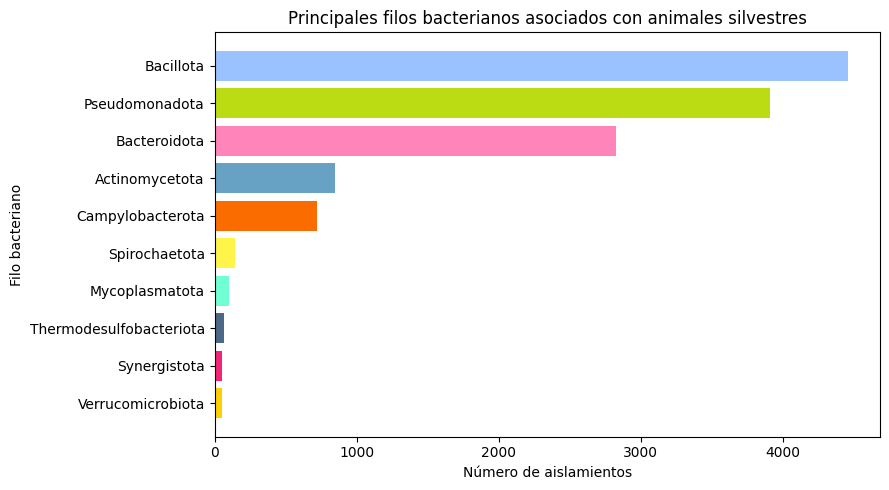

In [67]:
# Definir una paleta de colores pastel para cada filo
colores_phylum = {
    "Bacillota": "#99C2FF",
    "Pseudomonadota": "#BBDC12",
    "Bacteroidota": "#FF84BA",
    "Actinomycetota": "#67A2C5",
    "Campylobacterota": "#FB6C00",
    "Spirochaetota": "#FFF449",
    "Mycoplasmatota": "#70FFD2",
    "Thermodesulfobacteriota": "#4D6787",
    "Synergistota": "#F62477",
    "Verrucomicrobiota": "#FFCF00"
}

# Seleccionar los 10 filos con mayor frecuencia
# y ordenarlos de menor a mayor para la gráfica
top_phylum = frecuencia_phylum.head(10).sort_values()


# Asignar el color correspondiente a cada filo
colores = [
    colores_phylum[phylum]
    for phylum in top_phylum.index
]

import matplotlib.pyplot as plt

# Crear la figura
plt.figure(figsize=(9, 5))

# Generar una barra con un color pastel para cada filo
plt.barh(
    top_phylum.index,
    top_phylum.values,
    color=colores
)

# Agregar etiquetas y título
plt.xlabel("Número de aislamientos")
plt.ylabel("Filo bacteriano")
plt.title("Principales filos bacterianos asociados con animales silvestres")

# Ajustar la distribución de los elementos
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La distribución de los principales filos bacterianos mostró diferencias en su representación. Bacillota fue el filo con mayor frecuencia, seguido de Pseudomonadota y Bacteroidota. En contraste, Thermodesulfobacteriota, Synergistota y Verrucomicrobiota presentaron una representación considerablemente menor. En general, los resultados mostraron que una gran parte de los aislamientos perteneció a un grupo reducido de filos bacterianos.

## Distribución de los principales filos a través del tiempo

Se analizó la distribución temporal de los filos bacterianos con mayor representación en el conjunto de datos. Debido a la presencia de numerosos filos con frecuencias bajas, se seleccionaron los cinco más frecuentes para facilitar la comparación de sus tendencias a través de los años.


In [68]:
# Seleccionar los cinco filos con mayor frecuencia
top_5_phylum = frecuencia_phylum.head(5).index.tolist()

# Mostrar los filos seleccionados
top_5_phylum

['Bacillota',
 'Pseudomonadota',
 'Bacteroidota',
 'Actinomycetota',
 'Campylobacterota']

Los cinco filos seleccionados fueron Bacillota, Pseudomonadota, Bacteroidota, Actinomycetota y Campylobacterota. En conjunto, representaron aproximadamente el 94.13 % de los datos con información disponible para Phylum, por lo que concentraron la mayor parte de la composición taxonómica.

##### **Selección de los datos temporales**

Para el análisis temporal se conservaron únicamente los datos que contaron con año de colección y que pertenecieron a alguno de los cinco filos seleccionados.

In [69]:
# Seleccionar datos con año de colección disponible
# y pertenecientes a los cinco principales filos
temporal_phylum = wildlife_animales[
    wildlife_animales["Collection Year"].notna() &
    wildlife_animales["Phylum"].isin(top_5_phylum)
].copy()

# Mostrar las primeras observaciones seleccionadas
temporal_phylum[
    ["Collection Year", "Phylum"]
].head()

,Collection Year,Phylum
1,2017,Bacteroidota
2,1997,Pseudomonadota
3,1999,Bacteroidota
4,2000,Bacteroidota
5,1989,Bacteroidota


#####**Frecuencia de los principales filos por año**

Se calculó la cantidad de aislamientos pertenecientes a cada uno de los cinco filos seleccionados para cada año de colección. Esto permitió comparar su distribución temporal a partir de las frecuencias absolutas.

In [70]:
# Contar los aislamientos de cada filo para cada año
phylum_por_anio = (
    temporal_phylum
    .groupby(["Collection Year", "Phylum"])
    .size()
    .unstack(fill_value=0)
)

# Mostrar los primeros años
phylum_por_anio.head()

Phylum,Actinomycetota,Bacillota,Bacteroidota,Campylobacterota,Pseudomonadota
Collection Year,,,,,
1900,0,0,1,0,0
1930,2,0,0,0,0
1932,0,0,1,0,0
1938,0,0,0,0,1
1946,0,3,0,0,0


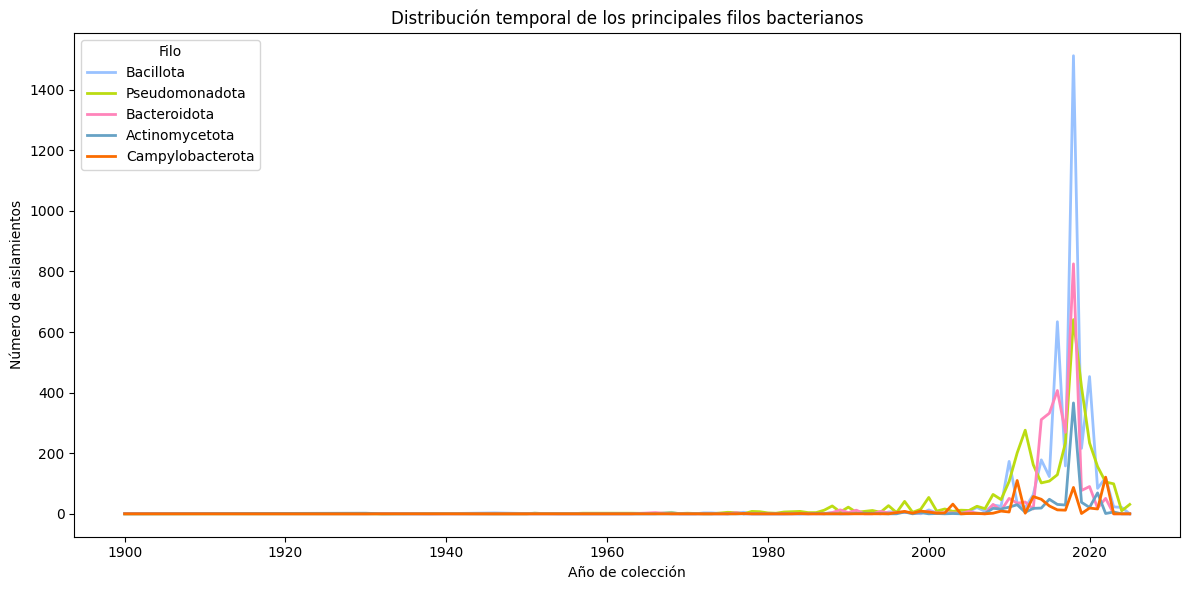

In [ ]:
import matplotlib.pyplot as plt

# Crear la figura
plt.figure(figsize=(12, 6))

# Graficar cada filo a través del tiempo
for phylum in top_5_phylum:
    plt.plot(
        phylum_por_anio.index,
        phylum_por_anio[phylum],
        label=phylum,
        color=colores_phylum[phylum],
        linewidth=2
    )

# Agregar etiquetas y título
plt.xlabel("Año de colección")
plt.ylabel("Número de aislamientos")
plt.title("Distribución temporal de los principales filos bacterianos")

# Mostrar la leyenda
plt.legend(title="Filo")

# Ajustar la distribución de los elementos
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La distribución temporal mostró diferencias en la cantidad de aislamientos disponibles entre los años. Durante las primeras décadas se observó una menor cantidad de datos, mientras que la mayor concentración se presentó en los años más recientes, especialmente entre 2015 y 2022. Bacillota presentó la mayor frecuencia durante los años con mayor cantidad de datos, seguido principalmente por Bacteroidota y Pseudomonadota. Esta distribución mostró un desbalance temporal en los datos, por lo que las diferencias entre los primeros años y los periodos recientes deben interpretarse considerando la cantidad de información disponible para cada año.

**Proporción anual**

Debido a que la cantidad total de aislamientos varió considerablemente entre los años, también calcularemos la proporción que representó cada filo dentro de los cinco filos seleccionados en cada año.

In [71]:
# Calcular el total de los cinco filos para cada año
total_por_anio = phylum_por_anio.sum(axis=1)

# Calcular la proporción de cada filo dentro de cada año
phylum_proporcion_anual = (
    phylum_por_anio
    .div(total_por_anio, axis=0)
    .mul(100)
    .round(2)
)

# Mostrar los primeros años
phylum_proporcion_anual.head()

Phylum,Actinomycetota,Bacillota,Bacteroidota,Campylobacterota,Pseudomonadota
Collection Year,,,,,
1900,0.0,0.0,100.0,0.0,0.0
1930,100.0,0.0,0.0,0.0,0.0
1932,0.0,0.0,100.0,0.0,0.0
1938,0.0,0.0,0.0,0.0,100.0
1946,0.0,100.0,0.0,0.0,0.0


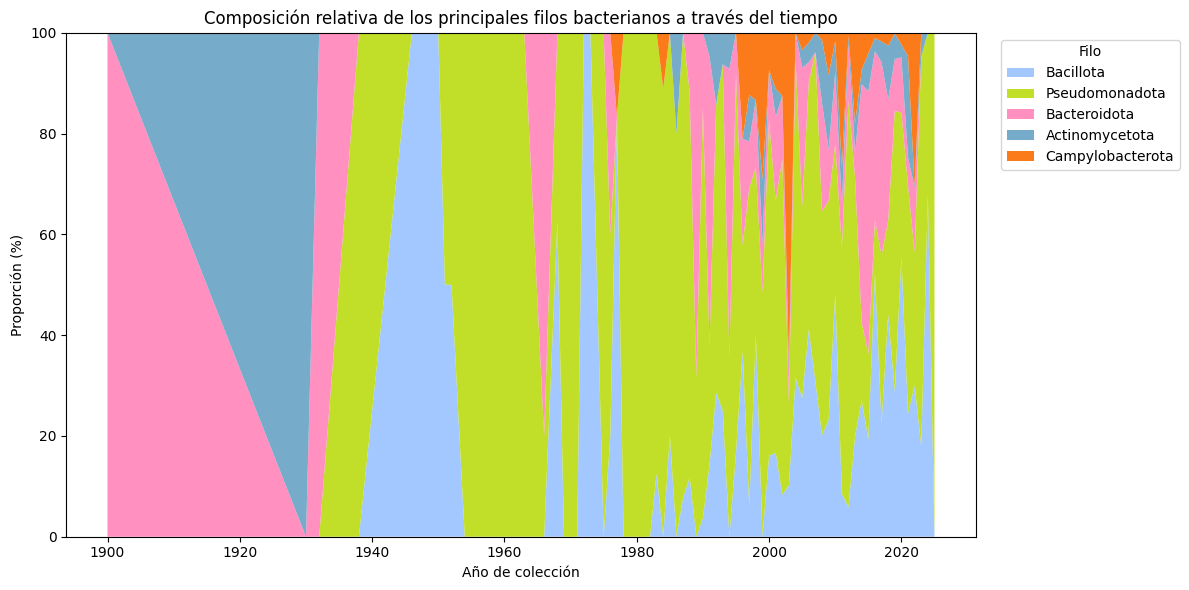

In [73]:
# Crear la figura
plt.figure(figsize=(12, 6))

# Obtener los años y las proporciones de cada filo
anios = phylum_proporcion_anual.index

# Graficar las proporciones acumuladas
plt.stackplot(
    anios,
    *[
        phylum_proporcion_anual[phylum]
        for phylum in top_5_phylum
    ],
    labels=top_5_phylum,
    colors=[
        colores_phylum[phylum]
        for phylum in top_5_phylum
    ],
    alpha=0.9
)

# Configurar el eje Y como porcentaje
plt.ylim(0, 100)

# Agregar etiquetas y título
plt.xlabel("Año de colección")
plt.ylabel("Proporción (%)")
plt.title("Composición relativa de los principales filos bacterianos a través del tiempo")

# Mostrar la leyenda
plt.legend(title="Filo", bbox_to_anchor=(1.02, 1), loc="upper left")

# Ajustar los elementos de la figura
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La composición relativa mostró variaciones en los cinco principales filos a través del tiempo. Sin embargo, en los años con pocos aislamientos, las proporciones fueron más extremas, ya que uno o pocos datos podían representar la mayoría o la totalidad de los aislamientos disponibles. Por esta razón, los primeros años deben interpretarse con precaución. En los años con mayor cantidad de datos, la visualización permitió observar diferencias en la composición relativa de los principales filos bacterianos.

## Relación entre el hospedero y los grupos bacterianos

#### Distribución de los principales filos según el grupo de hospedero

Se comparó la distribución de los cinco principales filos bacterianos entre los diferentes grupos de hospederos. Para ello, se utilizaron las variables Host Group y Phylum.

Como en el análisis temporal, se conservaron los cinco filos con mayor frecuencia para facilitar la comparación y mantener consistencia entre los análisis.

In [74]:
# Seleccionar los datos que cuentan con grupo de hospedero y filo bacteriano
host_phylum = wildlife_animales[
    wildlife_animales["Host Group"].notna() &
    wildlife_animales["Phylum"].isin(top_5_phylum)
].copy()

# Mostrar las primeras observaciones
host_phylum[
    ["Host Group", "Phylum"]
].head()

,Host Group,Phylum
0,Fish,Bacillota
1,Fish,Bacteroidota
2,Fish,Pseudomonadota
3,Fish,Bacteroidota
4,Fish,Bacteroidota


**Frecuencia de los principales filos según el grupo de hospedero**

Se calculó la cantidad de aislamientos pertenecientes a cada filo dentro de cada grupo de hospedero. Esto permitió conocer la distribución absoluta de los principales grupos bacterianos.

In [75]:
# Contar los aislamientos de cada filo dentro de cada grupo de hospedero
phylum_por_host = (
    host_phylum
    .groupby(["Host Group", "Phylum"])
    .size()
    .unstack(fill_value=0)
)

# Mostrar la tabla resultante
phylum_por_host

Phylum,Actinomycetota,Bacillota,Bacteroidota,Campylobacterota,Pseudomonadota
Host Group,,,,,
Avian,6,101,47,293,734
Fish,1,306,1082,0,777
Insect,180,585,26,0,648
Nonhuman Mammal,555,3211,1370,414,1255
Sea Mammal,22,42,52,8,134
Tick,0,0,0,0,1


La distribución mostró diferencias en la cantidad de aislamientos entre los grupos de hospederos. Nonhuman Mammal presentó la mayor cantidad de datos, mientras que Tick presentó una representación mínima.

Por ejemplo, dentro de Nonhuman Mammal, Bacillota presentó 3,211 aislamientos, mientras que en Fish el filo con mayor frecuencia fue Bacteroidota, con 1,082 aislamientos. En Avian, Pseudomonadota presentó la mayor frecuencia, con 734 aislamientos.

**Proporción de los principales filos dentro de cada grupo de hospedero**

Debido a que los grupos de hospederos presentaron cantidades diferentes de aislamientos, se calcularon también las proporciones correspondientes a cada filo dentro de cada grupo.

In [76]:
# Calcular el total de aislamientos de los cinco filos para cada grupo de hospedero
total_por_host = phylum_por_host.sum(axis=1)

# Calcular la proporción de cada filo dentro de cada grupo de hospedero
phylum_proporcion_host = (
    phylum_por_host
    .div(total_por_host, axis=0)
    .mul(100)
    .round(2)
)

# Mostrar las proporciones
phylum_proporcion_host

Phylum,Actinomycetota,Bacillota,Bacteroidota,Campylobacterota,Pseudomonadota
Host Group,,,,,
Avian,0.51,8.55,3.98,24.81,62.15
Fish,0.05,14.13,49.95,0.00,35.87
Insect,12.51,40.65,1.81,0.00,45.03
Nonhuman Mammal,8.16,47.19,20.13,6.08,18.44
Sea Mammal,8.53,16.28,20.16,3.10,51.94
Tick,0.00,0.00,0.00,0.00,100.00


La composición relativa mostró diferencias entre los grupos de hospederos. Bacteroidota presentó una mayor proporción en peces, mientras que Bacillota tuvo una mayor proporción en mamíferos no humanos. Pseudomonadota presentó una proporción elevada en aves, insectos y mamíferos marinos.

####Visualización de la composición bacteriana según el grupo de hospedero

Para facilitar la comparación entre grupos de hospederos y filos bacterianos, se utilizó un mapa de calor (heatmap). En esta visualización, las filas representaron los grupos de hospederos, las columnas representaron los principales filos bacterianos y la intensidad del color indicó la proporción de cada filo.

Debido a que Tick estuvo representado por un solo aislamiento, se excluyó únicamente de esta visualización para evitar que su proporción del 100 % generara una interpretación visual desproporcionada. Esta exclusión correspondió únicamente a la gráfica y no modificó la base de datos ni los análisis anteriores.

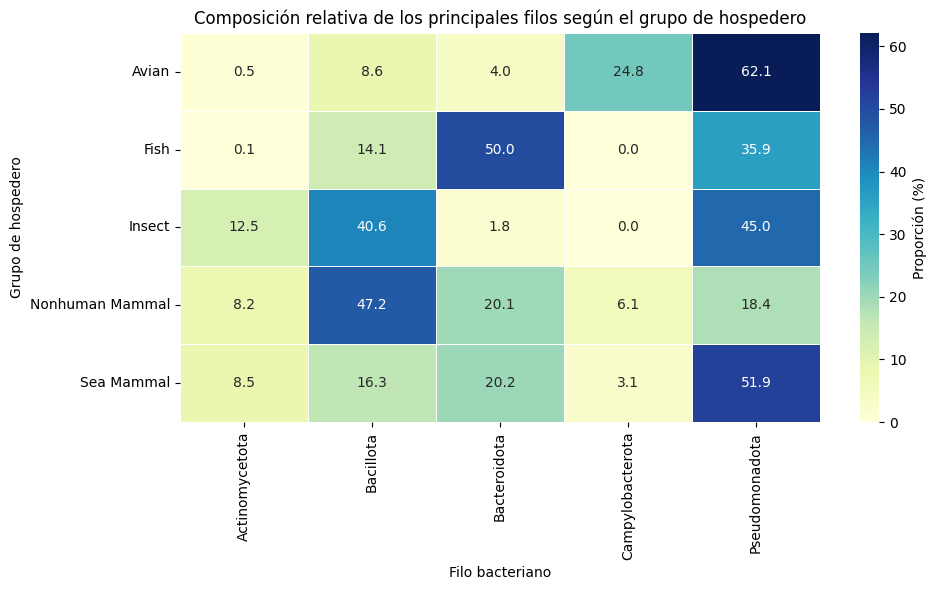

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Excluir Tick únicamente de esta visualización
# debido a que cuenta con un solo aislamiento
heatmap_host = phylum_proporcion_host.drop(index="Tick")

# Crear la figura
plt.figure(figsize=(10, 6))

# Generar el mapa de calor
sns.heatmap(
    heatmap_host,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Proporción (%)"}
)

# Agregar etiquetas y título
plt.xlabel("Filo bacteriano")
plt.ylabel("Grupo de hospedero")
plt.title("Composición relativa de los principales filos según el grupo de hospedero")

# Ajustar la figura
plt.tight_layout()

# Mostrar
plt.show()

El heatmap mostró diferencias en la composición relativa de los principales filos bacterianos entre los grupos de hospederos. Pseudomonadota presentó la mayor proporción en Avian (62.1 %) y Sea Mammal (51.9 %), mientras que Bacteroidota predominó en Fish (50.0 %). En Insect, los filos con mayor representación fueron Pseudomonadota (45.0 %) y Bacillota (40.6 %). En Nonhuman Mammal, Bacillota presentó la mayor proporción (47.2 %).

También se observó una mayor proporción de Campylobacterota en Avian (24.8 %) en comparación con los demás grupos. En conjunto, los resultados mostraron diferencias en la composición relativa de los principales filos entre los grupos de hospederos. Sin embargo, debido a que los grupos tuvieron diferentes cantidades de aislamientos y algunas categorías estuvieron poco representadas, estos patrones se interpretaron como diferencias observadas en los datos analizados y no como evidencia de una relación causal entre el hospedero y la composición bacteriana.